### `About the Dataset`

* `A real dataset of anonymized credit card transactions made by European cardholders from September 2013`
* `These transactions are labeled as fraudulent (Class = 1) or genuine (Class = 0)`
* `There are 30 numerical features and no categorical variables: V1 to V28 are the output of principal component analysis (PCA), while Time and Amount are the only features that are NOT PCA outputs`
* `The original features are not provided (confidentiality)`

> `In the real world, fraud often goes undiscovered, and only the fraud that is caught provides any labels for the datasets. Moreover, fraud patterns change over time, so supervised systems that are built using fraud labels fail to adapt to newly emerging patterns, For these reasons (the lack of sufficient labels and the need to adapt to newly emerging patterns of fraud as quickly as possible), unsupervised learning fraud detection systems are in vogue. (Anomaly Detection)`

### `Build a credit card fraud detection system without using labels (Anomaly Detection)`

----

### `Import the main Libraries`

In [1]:
## Major
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os

## sklearn -- preparing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

## sklearn -- metrics 
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
from sklearn.metrics import average_precision_score, precision_score, recall_score

## sklearn -- Dimens. Reduction
from sklearn.decomposition import PCA, SparsePCA, KernelPCA, MiniBatchDictionaryLearning, FastICA
from sklearn.random_projection import GaussianRandomProjection

### `Read the Dataset and Look at the big Picture`

In [2]:
## Read the Dataset
FILE_PATH = os.path.join(os.getcwd(), "..", "Data", "creditcard.csv")
df_credit = pd.read_csv(FILE_PATH)

## check the head
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
## Check some info, datatypes and nulls
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
## Check some statistics about the data
df_credit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### `Exploratory Data Analysis (EDA)`

#### `1. Shape, Missing Values & Duplicates`

In [5]:
## Feature groups -- V1:V28 are the PCA outputs, Time & Amount are the only raw features
pca_features = [f'V{i}' for i in range(1, 29)]
raw_features = ['Time', 'Amount']
all_features = pca_features + raw_features

## Shape, missing values, duplicated rows
print(f"Rows: {df_credit.shape[0]:,} | Columns: {df_credit.shape[1]}")
print(f"Missing values: {df_credit.isna().sum().sum()}")
print(f"Duplicated rows: {df_credit.duplicated().sum():,}")
print(f"Time window covered: {df_credit['Time'].max() / 3600:.1f} hours")

Rows: 284,807 | Columns: 31
Missing values: 0
Duplicated rows: 1,081
Time window covered: 48.0 hours


#### `2. Class Distribution (How rare is the fraud?)`
`The labels are used for EDA and evaluation only -- they are never used to train the unsupervised models.`

,Count,Percentage (%)
Normal (0),284315,99.8273
Fraud (1),492,0.1727


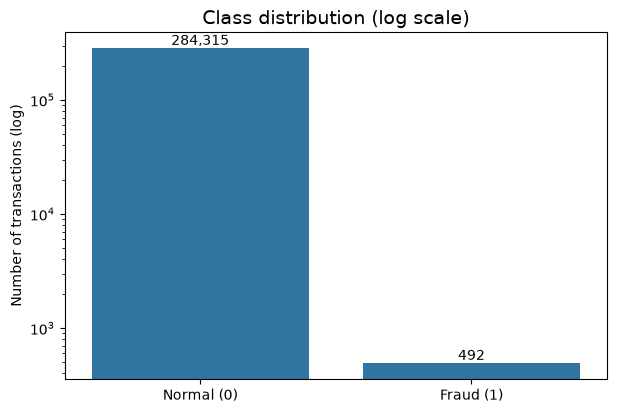

In [6]:
## Count and percentage of each class
class_summary = pd.DataFrame({
    'Count': df_credit['Class'].value_counts().sort_index(),
    'Percentage (%)': (df_credit['Class'].value_counts(normalize=True).sort_index() * 100).round(4)
})
class_summary.index = ['Normal (0)', 'Fraud (1)']
display(class_summary)

## Plot (log scale, otherwise the fraud bar is invisible)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(x='Class', data=df_credit, ax=ax)
ax.set_yscale('log')
ax.set_xticks([0, 1], labels=['Normal (0)', 'Fraud (1)'])
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
ax.set_title('Class distribution (log scale)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Number of transactions (log)')
plt.show()

#### `3. Amount`

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


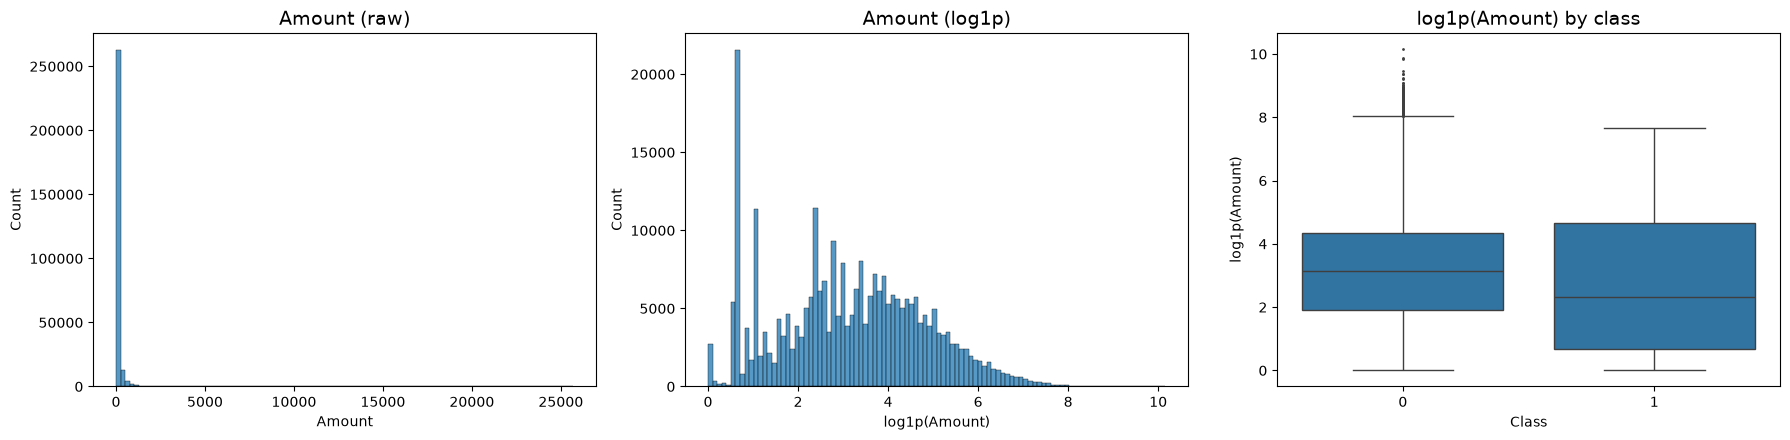

In [7]:
## Amount statistics for each class
display(df_credit.groupby('Class')['Amount'].describe().round(2))

## Amount is highly right-skewed, so look at it also on a log scale
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.histplot(df_credit['Amount'], bins=100, ax=axes[0])
axes[0].set_title('Amount (raw)', fontsize=14)

sns.histplot(np.log1p(df_credit['Amount']), bins=100, ax=axes[1])
axes[1].set_title('Amount (log1p)', fontsize=14)
axes[1].set_xlabel('log1p(Amount)')

sns.boxplot(x=df_credit['Class'], y=np.log1p(df_credit['Amount']), fliersize=1, ax=axes[2])
axes[2].set_title('log1p(Amount) by class', fontsize=14)
axes[2].set_ylabel('log1p(Amount)')

plt.tight_layout()
plt.show()

#### `4. Time`
`Time = seconds elapsed since the first transaction in the dataset (it is NOT a clock time).`

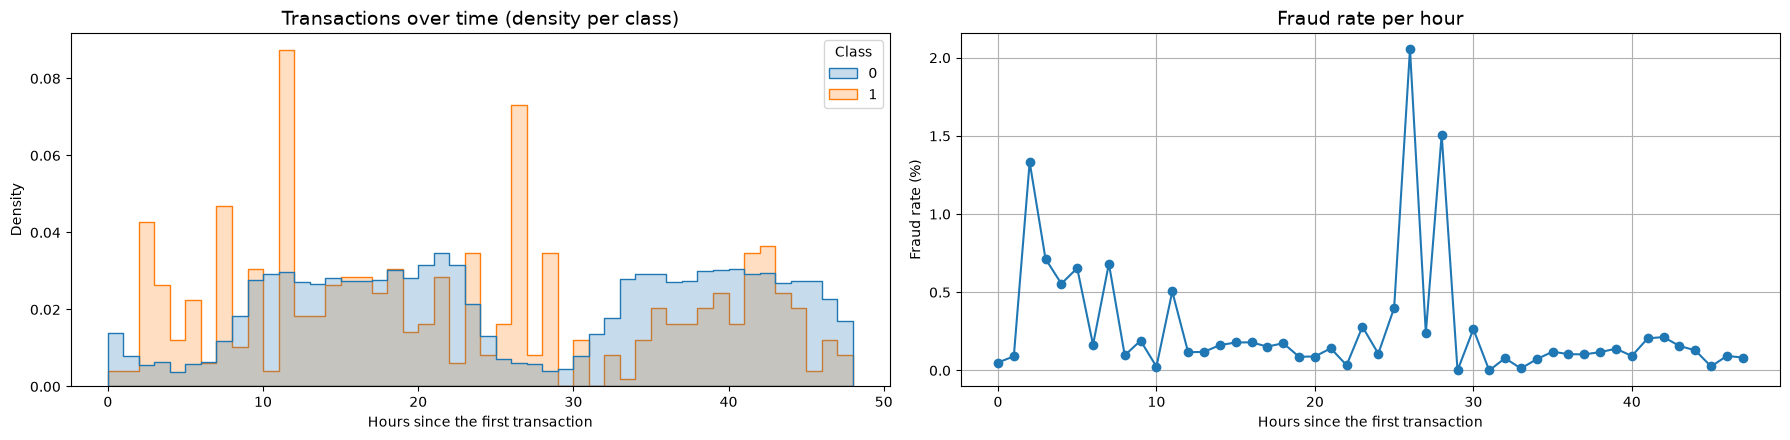

In [8]:
## Fraud rate for each hour since the first transaction
hours_since_start = (df_credit['Time'] // 3600).astype(int)
hourly = pd.crosstab(hours_since_start, df_credit['Class'])
hourly.columns = ['Normal', 'Fraud']
hourly['Fraud rate (%)'] = hourly['Fraud'] / (hourly['Normal'] + hourly['Fraud']) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))

## the two curves are normalized (density) so the shapes can be compared although the classes are imbalanced
sns.histplot(data=df_credit.assign(Hours=df_credit['Time'] / 3600), x='Hours', hue='Class', bins=48,
             stat='density', common_norm=False, element='step', ax=axes[0])
axes[0].set_title('Transactions over time (density per class)', fontsize=14)
axes[0].set_xlabel('Hours since the first transaction')

axes[1].plot(hourly.index, hourly['Fraud rate (%)'], marker='o')
axes[1].set_title('Fraud rate per hour', fontsize=14)
axes[1].set_xlabel('Hours since the first transaction')
axes[1].set_ylabel('Fraud rate (%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### `5. Which Features Separate Fraud from Normal?`
`Standardized mean difference between the fraud and normal groups (a Cohen's d style effect size). The further from zero, the more the feature differs for fraud.`

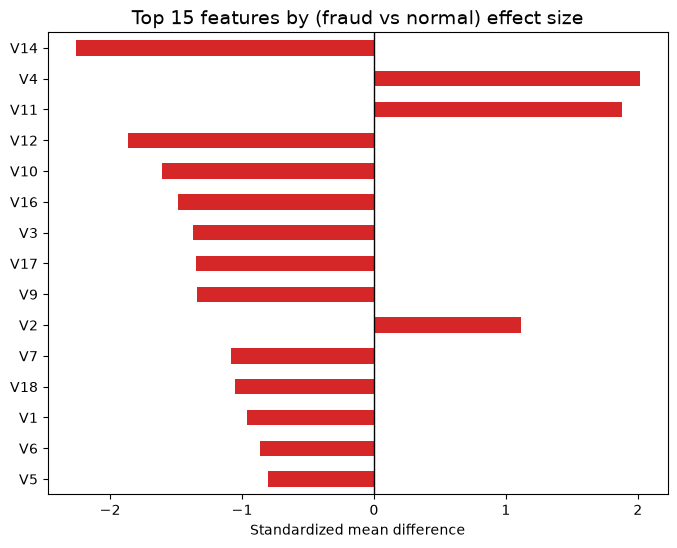

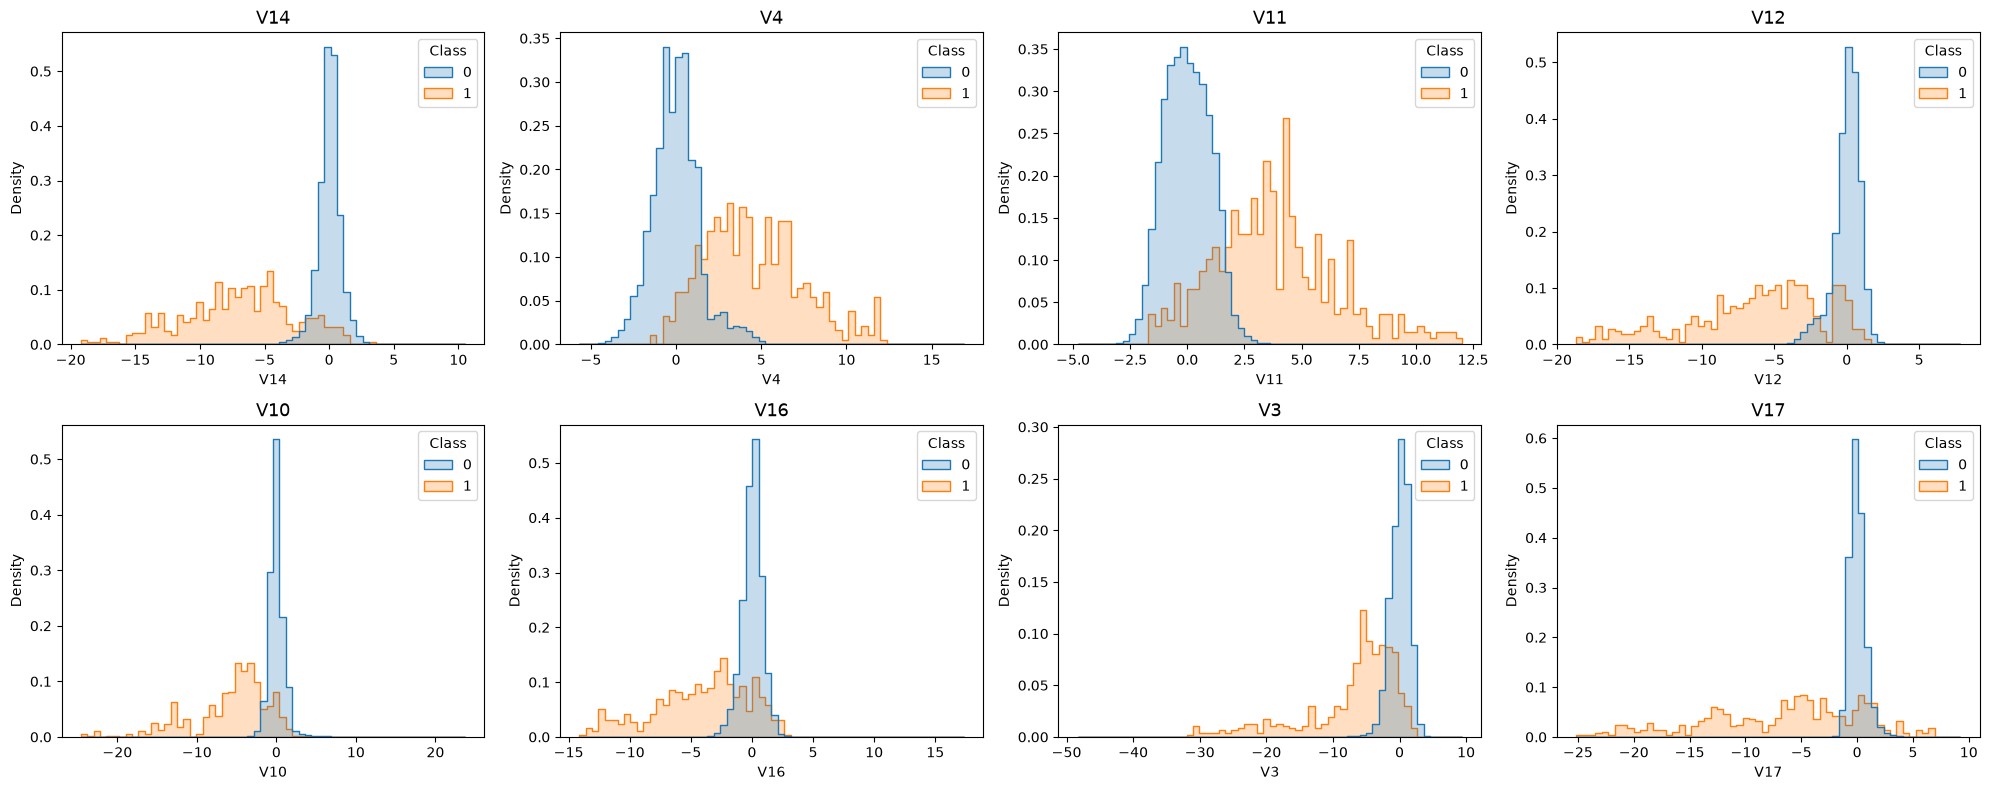

In [9]:
normal_tx = df_credit[df_credit['Class'] == 0]
fraud_tx = df_credit[df_credit['Class'] == 1]

## effect size = (mean_fraud - mean_normal) / pooled std
pooled_std = np.sqrt((normal_tx[all_features].var() + fraud_tx[all_features].var()) / 2)
effect_size = (fraud_tx[all_features].mean() - normal_tx[all_features].mean()) / pooled_std
effect_size = effect_size.reindex(effect_size.abs().sort_values(ascending=False).index)

## Top 15 features
plt.figure(figsize=(8, 6))
effect_size.head(15).iloc[::-1].plot(kind='barh', color='tab:red')
plt.axvline(0, color='k', linewidth=1)
plt.title('Top 15 features by (fraud vs normal) effect size', fontsize=14)
plt.xlabel('Standardized mean difference')
plt.show()

## Distribution of the top 8 features for each class (density, because the classes are imbalanced)
top_features = effect_size.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.ravel(), top_features):
    sns.histplot(data=df_credit, x=col, hue='Class', bins=60, stat='density',
                 common_norm=False, element='step', ax=ax)
    ax.set_title(col, fontsize=13)
plt.tight_layout()
plt.show()

#### `6. Correlations`
`The PCA components V1 to V28 are (almost) uncorrelated with each other by construction, so the interesting structure is between Time, Amount, the V features and the Class.`

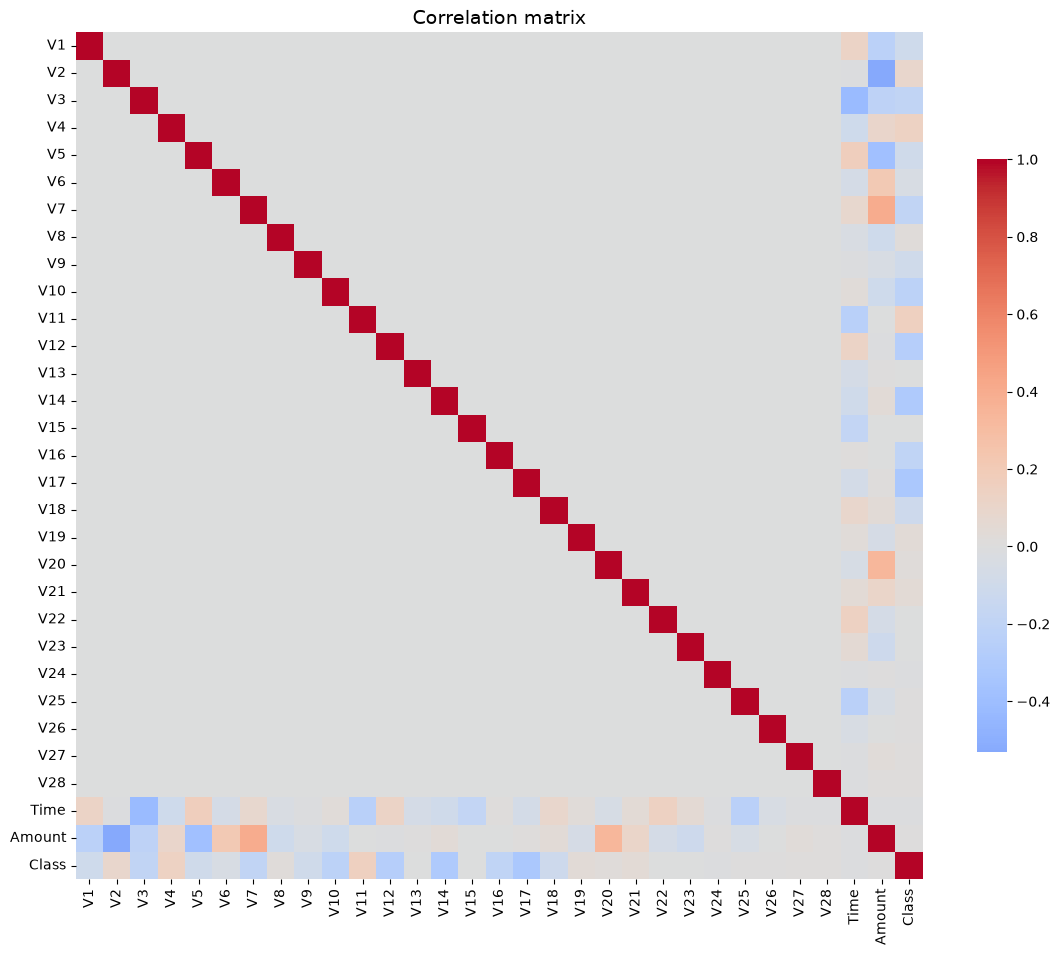

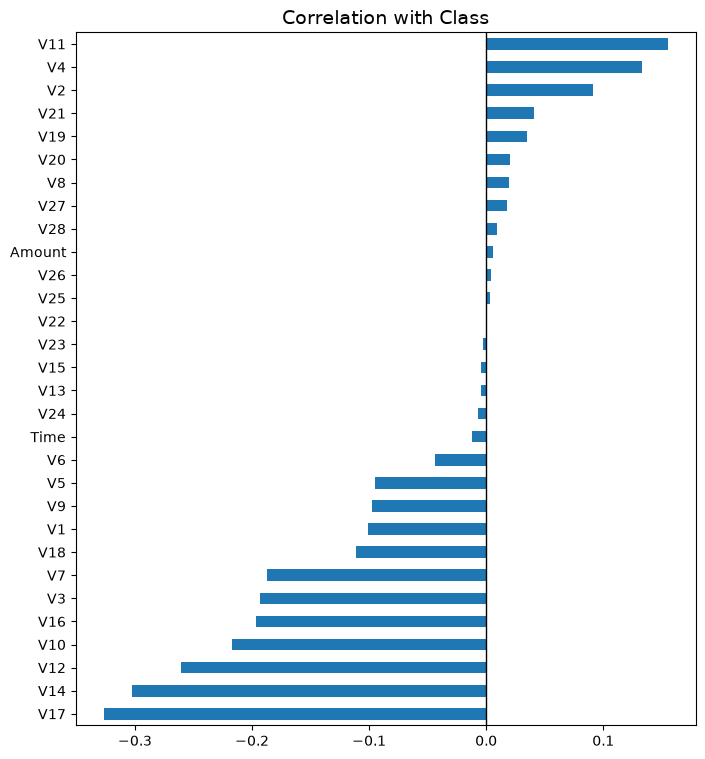

In [10]:
corr = df_credit[all_features + ['Class']].corr()

## Full correlation heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation matrix', fontsize=14)
plt.show()

## Correlation of each feature with the Class
class_corr = corr['Class'].drop('Class').sort_values()
plt.figure(figsize=(8, 9))
class_corr.plot(kind='barh')
plt.axvline(0, color='k', linewidth=1)
plt.title('Correlation with Class', fontsize=14)
plt.show()

#### `7. Are Frauds More "Extreme"? (The Idea Behind Reconstruction Error)`
`Anomaly detection assumes fraud looks different from the majority. Here we count, for each transaction, how many of the V features are more than 3 standard deviations away from their mean.`

,Normal (%),Fraud (%)
>= 1 feature(s) with |z| > 3,12.73,90.04
>= 3 feature(s) with |z| > 3,2.69,83.13
>= 5 feature(s) with |z| > 3,1.33,71.14


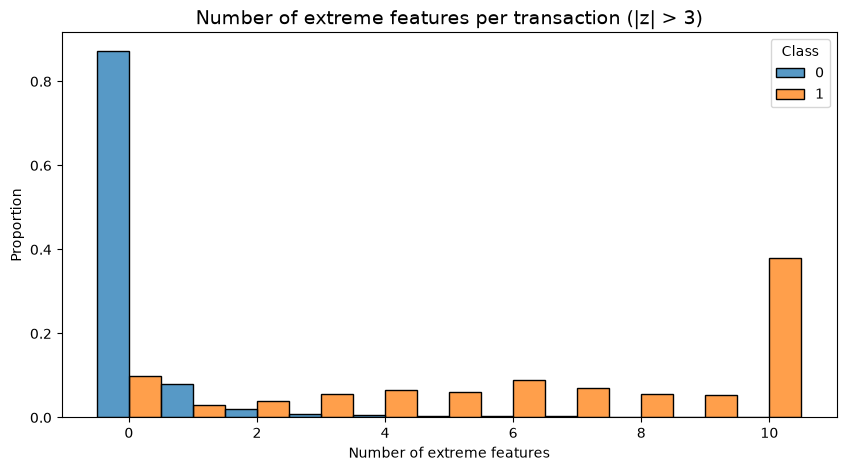

In [11]:
## z-score for each PCA feature, then count the extreme values for each transaction
z_scores = (df_credit[pca_features] - df_credit[pca_features].mean()) / df_credit[pca_features].std()
n_extreme = (z_scores.abs() > 3).sum(axis=1)

## Percentage of transactions having at least k extreme features (for each class)
extreme_summary = pd.DataFrame({
    f'>= {k} feature(s) with |z| > 3': (n_extreme >= k).groupby(df_credit['Class']).mean() * 100
    for k in (1, 3, 5)
}).T
extreme_summary.columns = ['Normal (%)', 'Fraud (%)']
display(extreme_summary.round(2))

## Distribution of the number of extreme features (10 means 10 or more)
plt.figure(figsize=(10, 5))
sns.histplot(data=pd.DataFrame({'n_extreme': n_extreme.clip(upper=10), 'Class': df_credit['Class']}),
             x='n_extreme', hue='Class', discrete=True, stat='proportion',
             common_norm=False, multiple='dodge')
plt.title('Number of extreme features per transaction (|z| > 3)', fontsize=14)
plt.xlabel('Number of extreme features')
plt.show()

#### `EDA Takeaways for the Modelling Part`
* `Fraud is extremely rare, so accuracy is meaningless -- we evaluate with the precision-recall curve (average precision) and ROC AUC`
* `Amount is heavily skewed and Time is on a completely different scale from the V features, so the data must be standardized before PCA (see the link below)`
* `V1 to V28 are already PCA outputs, so any structure left between them is small -- the reconstruction error approach relies on fraud being "different" from the majority (see section 7)`
* `The EDA above uses the whole dataset only to look at the data. Nothing from it is used for fitting -- the scaler and every model are fitted on the training split only`

[Standardize before PCA](https://stackoverflow.com/questions/39470999/scale-before-pca#:~:text=The%20rule%20of%20thumb%20is,normalize%20it%20before%20running%20PCA.)

### `Prepare the Dataset`

In [12]:
## Split the Data to Features and Target
X = df_credit.drop(columns=['Class'])
y = df_credit['Class']

## Split the Dataset to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2018, stratify=df_credit['Class'])

In [13]:
## Pipeline

num_pipeline = Pipeline(steps=[
                              ('scaler', StandardScaler())
                              ]
                        )
## fit and transform
X_train_final = num_pipeline.fit_transform(X_train)
X_test_final = num_pipeline.transform(X_test)

### `Define Anomaly Detection Score Function`

`Read carefully the following Notes`

* `The more anomalous the transaction is, the more likely it is to be fraudulent.`
* `Assuming that fraud is rare and looks somewhat different than the majority of transactions, which are normal.`
* `Dimensionality Reduction algorithms reduce the dimensionality of data while trying to minimize the (reconstruction  error)`

* `In other words, these algorithms try to capture the (most of variance) of the original features in such a way that they can reconstruct the original feature set from the reduced feature set as well as possible.`
* `However, these dimensionality reduction algorithms (cannot capture all the information of the original features) as they move to a lower dimensional space; therefore, there will be (some error) as these algorithms reconstruct the reduced feature set back to the original number of dimensions`

### `Zero is normal and one is anomalous (and most likely to be fraudulent)`


In [14]:
## Define a score function for anomaly detection
## let’s define the anomaly score as the (reconstruction error)
## The reconstruction error for each transaction is the sum of the squared differences 
## between the original feature matrix and the reconstructed matrix using the dimensionality reduction algorithm.
## I will scale the sum of the squared differences by the (max-min range) of the sum of the squared differences 
## for the entire dataset, so that all the reconstruction errors are within a zero to one range.

In [15]:
## Creat the Anomaly Function
def reconstruction_error(X_original, X_reconstructed):
    """ Sum of the squared differences between the original and the reconstructed features, for each instance. """
    return np.sum((np.asarray(X_original) - np.asarray(X_reconstructed)) ** 2, axis=1)  ## axis=1 -- I need for each instance (take care)


def anomaly_scores(X_original, X_reconstructed, loss_min=None, loss_max=None):
    """ This function is for getting the score for each instance in the dataset
        it compares the instance in the original dataset with the instance after reconstructed
        using Dimensonality Reduction Algorithm.

        The Function normalize the output with the (max_min range, between 0-1)
        The loss = zero --> means that this instance is normal (not fraud) as the original is equal to reconstructed
        The loss = one  --> means that this instance is almost anomaly (fraud) as the original is not equal to reconstructed

    Args:
    *****
        (X_original: 2d NumPy array) --> The original Features of the Dataset
        (X_reconstructed: 2d NumPy array) --> The Reconstructed Features after applying Dimesn. Reduction Algorithm
        (loss_min, loss_max: float, optional) --> The range used for the min-max scaling.
            By default it is taken from the given data. For new data (the test set), pass the range of the TRAIN losses,
            so that train and test scores are on the same scale (test scores can then be slightly outside 0-1).

    Returns:
    *******
        Returns the loss for each instance in range (0, 1), 0 is perfectly normal, 1 is perfectly anomaly.

    """

    loss = reconstruction_error(X_original, X_reconstructed)
    loss_min = np.min(loss) if loss_min is None else loss_min
    loss_max = np.max(loss) if loss_max is None else loss_max

    if loss_max == loss_min:  ## avoid division by zero (all instances have the same error)
        return np.zeros_like(loss, dtype=float)

    return (loss - loss_min) / (loss_max - loss_min)  ## Normalize using (min-max range)


### `Define Evaluation Metrics`
`we will use the labels to evaluate the unsupervised solutions we develop. The labels will help us understand
just how well these solutions are at catching known patterns of fraud.`

In [16]:
## Define a full function for evaluation (plotting precision_recall curve, ROC_curve)
def evaluate_score(y_true, y_anomaly_scores, return_df=False):
    """ This Function tries to plot both (precision_recall curve, ROC_curve),
        and return df of both (y_true, y_anomaly_scores) if it is required
    Args:
    *****
        (y_true: 1D NumPy array) --> The True values (just for evaluating)
        (y_anomaly_scores: 1D NumPy array) --> The output from the previous Function (the anomaly scores for each instance)
        (return_df: boolean): If it is requires to return the concatenating (y_true, y_anomaly_scores)

    Returns:
    ********
        Plotting of -- precision_recall curve & ROC_curve
    """
    ## concat the true and scores (np.asarray -- to ignore the index of the Series, the order is the same)
    df = pd.DataFrame({'True Labels': np.asarray(y_true), 'Anomaly Scores': np.asarray(y_anomaly_scores)})

    ## Precision and Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true=df['True Labels'], y_score=df['Anomaly Scores'])

    ## Average Precision is the area under (precision-recall curve)
    average_precision = average_precision_score(y_true=df['True Labels'], y_score=df['Anomaly Scores'])

    ## Plotting the precision-recall curve
    plt.figure(figsize=(10, 6))
    plt.step(recall, precision, color='k', alpha=0.7, where='post')
    plt.fill_between(recall, precision, step='post', alpha=0.3, color='k')
    plt.title(f'Precision-Recall curve: Average Precision = {average_precision:.2f}', fontsize=14)
    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.grid(True)
    plt.show()


    ## ROC curve
    fpr, tpr, thresholds = roc_curve(y_true=df['True Labels'], y_score=df['Anomaly Scores'])
    ## area under curve
    auc = roc_auc_score(y_true=df['True Labels'], y_score=df['Anomaly Scores'])

    ## plotting roc curve
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='r', linewidth=2, label='ROC curve')
    plt.plot([0, 1], [0, 1], color='k', linewidth=2, linestyle='--')
    plt.scatter(0, 0, s=40, c='k')
    plt.scatter(1, 1, s=40, c='k')
    plt.title(f'Receiver operating characteristic: Area under the curve {auc:.2f}', fontsize=14)
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate = Recall', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    if return_df:
        return df


### `Define a ScatterPlot Function to plot between the First & Second Component`
`As we did in the Dimens. Reduction -- Draw a scatterPlot between only the First and Second Vector`

In [17]:
## Define a ScatterPlot Function

def plot_two_comp(X_reduced, y_true, algo_name):
    """ This Function tries to plot scatterPlot for First & Second Components using Dimen. Reduction Algorithm
        with different colors according to the true labels (true labels in this project are just for evaluating)

    Args:
    *****
        (X_reduced: 2d NumPy array) ---> The reduced features after applying Dimen. Reduction Algorithm
        (y_true: 1D NumPy array) --> The True values (just for evaluating)
        (algo_name: str) --> The name used in the title

    Returns:
    ********
        ScatterPlot for the First & Second Vector according to each label
    """
    ## Plotting the (First Vector & Second Vector) corresponding to each (label)
    df_two_vectors = pd.DataFrame({'First Vector': np.asarray(X_reduced)[:, 0],
                                   'Second Vector': np.asarray(X_reduced)[:, 1],
                                   'Label': np.asarray(y_true).astype(int)})

    normal = df_two_vectors[df_two_vectors['Label'] == 0]
    fraud = df_two_vectors[df_two_vectors['Label'] == 1]

    ## normal first, then the rare fraud points on top (so they are not hidden)
    plt.figure(figsize=(8, 6))
    plt.scatter(normal['First Vector'], normal['Second Vector'], s=4, alpha=0.3, c='tab:blue', label='Normal (0)', rasterized=True)
    plt.scatter(fraud['First Vector'], fraud['Second Vector'], s=14, alpha=0.8, c='tab:red', label='Fraud (1)')
    plt.title(f'Using {algo_name}', fontsize=14, c='k')
    plt.xlabel('First Vector')
    plt.ylabel('Second Vector')
    plt.legend()
    plt.show()


### `Take Care`
* `Remember that the features V1 to V28 in the credit card transactions dataset we have are already the output of PCA (only Time and Amount are raw features)`
* `There is nothing unusual about performing PCA for anomaly detection on an already dimensionality-reduced dataset`
* `We just treat the original principal components that we are given as the original features`

-----

### `PCA`

`But How to select the number of components, Of course, if you take the number of components is equal to the original number of features in the dataset, almost there is no reconstruction error (capture 100% of variance), and If you take the number of components very low, the reconstruction error will be high (capture less variance), it is hyperparameters it needs to be tuned`

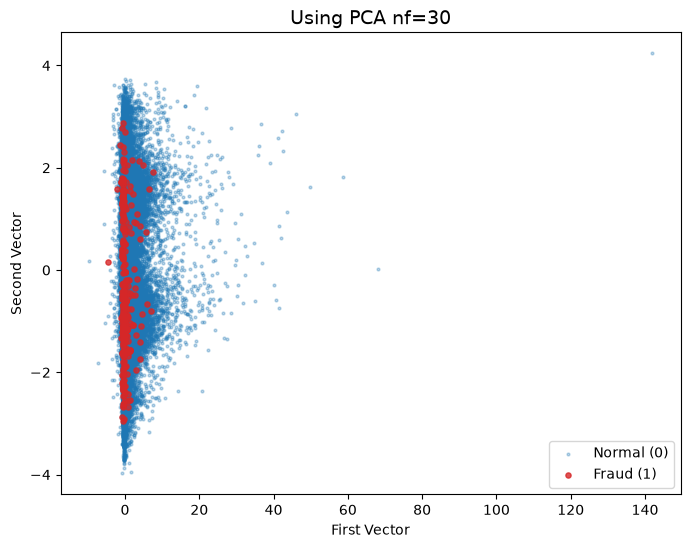

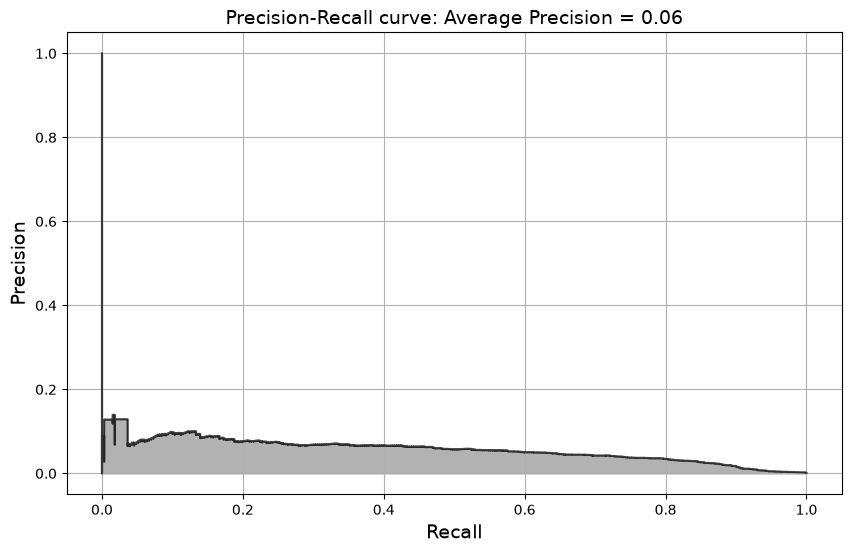

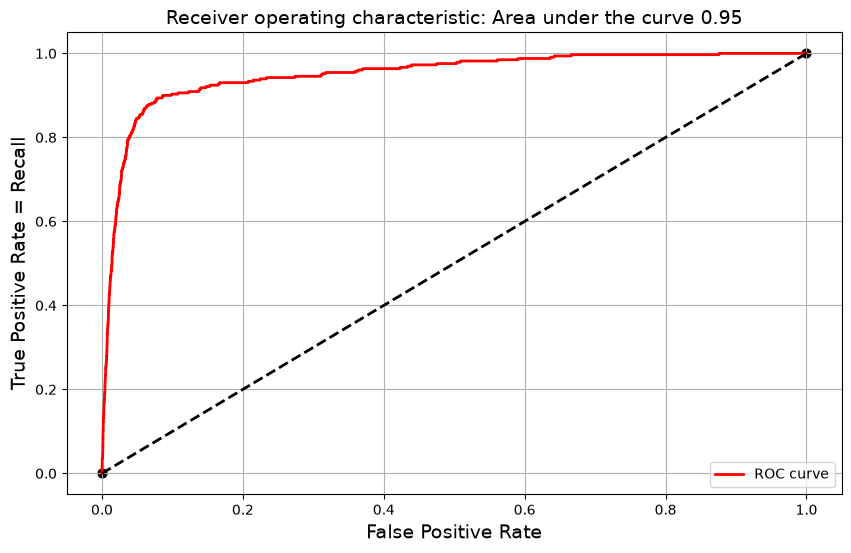

In [18]:
## Try PCA with 100% Features (30 Features)
pca_30 = PCA(n_components=30, random_state=2018)  ## the same random_state as the other models

## Fit and transform for train, transform only for test
X_train_reduced_pca30 = pca_30.fit_transform(X_train_final)

## Inverse (Reconstruct)
X_train_inverse_pca30 = pca_30.inverse_transform(X_train_reduced_pca30)

## Call the ScatterPlot Function
plot_two_comp(X_reduced=X_train_reduced_pca30, y_true=y_train, algo_name='PCA nf=30')

## Getting Anomaly Scores -- call the function
y_scores_pca30 = anomaly_scores(X_original=X_train_final, X_reconstructed=X_train_inverse_pca30)

## Plotting Evaluation plots -- call the function
evaluate_score(y_true=y_train, y_anomaly_scores=y_scores_pca30)

* > `We need the PCA-based fraud detection solution to have enough error on the rare cases that it can meaningfully separate fraud cases from the normal ones. But the error cannot be so low or so high for all the transactions`

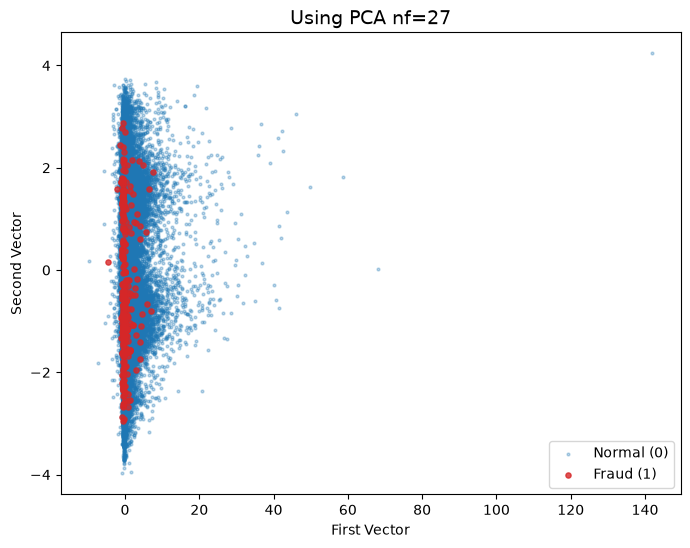

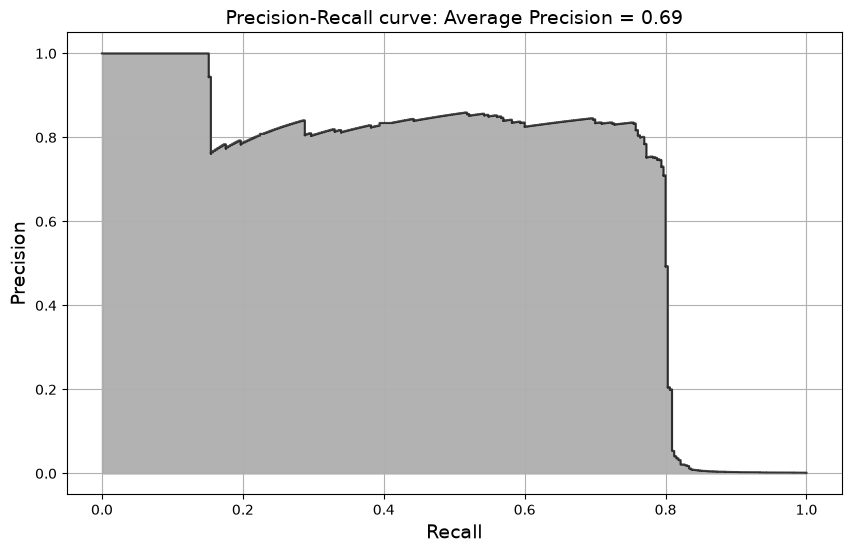

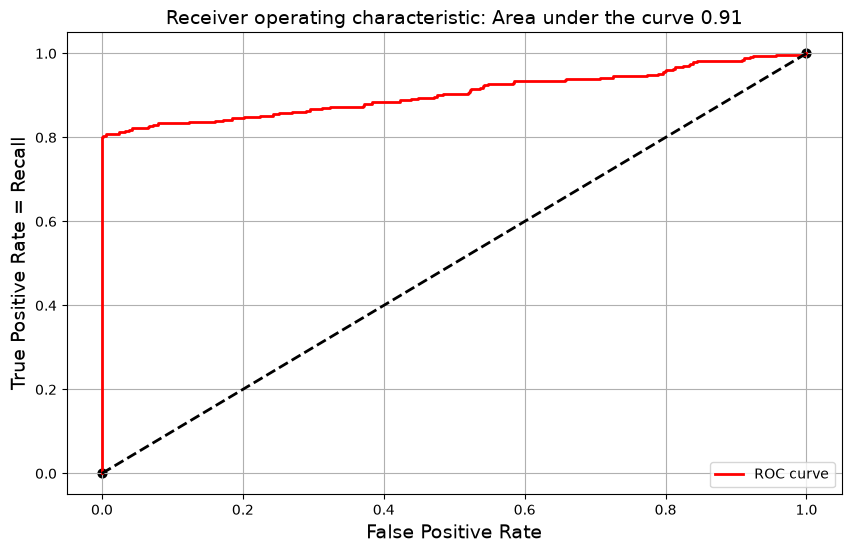

,True Labels,Anomaly Scores
0,0,0.000179
1,0,0.000029
2,0,0.000182
3,0,0.000135
4,0,0.000418
...,...,...
190815,0,0.000102
190816,0,0.000039
190817,0,0.000110
190818,0,0.000149


In [19]:
## Try PCA with 27 Features
pca_27 = PCA(n_components=27, random_state=2018)  ## The same random_state

## Fit and transform for train, transform only for test
X_train_reduced_pca_27 = pca_27.fit_transform(X_train_final)

## Inverse (Reconstruct)
X_train_inverse_pca_27 = pca_27.inverse_transform(X_train_reduced_pca_27)

## Call the ScatterPlot Function
plot_two_comp(X_reduced=X_train_reduced_pca_27, y_true=y_train, algo_name='PCA nf=27')

## Getting Anomaly Scores -- call the function
y_scores_pca27 = anomaly_scores(X_original=X_train_final, X_reconstructed=X_train_inverse_pca_27)

## Plotting Evaluation plots -- call the function
df_pca27 = evaluate_score(y_true=y_train, y_anomaly_scores=y_scores_pca27, return_df=True)
df_pca27

In [20]:
## Sort descending according to scores
df_pca27 = df_pca27.sort_values(by='Anomaly Scores', ascending=False)
df_pca27

,True Labels,Anomaly Scores
53084,1,1.000000e+00
143493,1,9.017986e-01
21774,1,9.017986e-01
87283,1,9.017986e-01
155989,1,9.017986e-01
...,...,...
62495,0,2.307548e-08
50570,0,2.291151e-08
110088,0,1.849888e-08
59785,0,3.777973e-09


### `Sparse PCA`

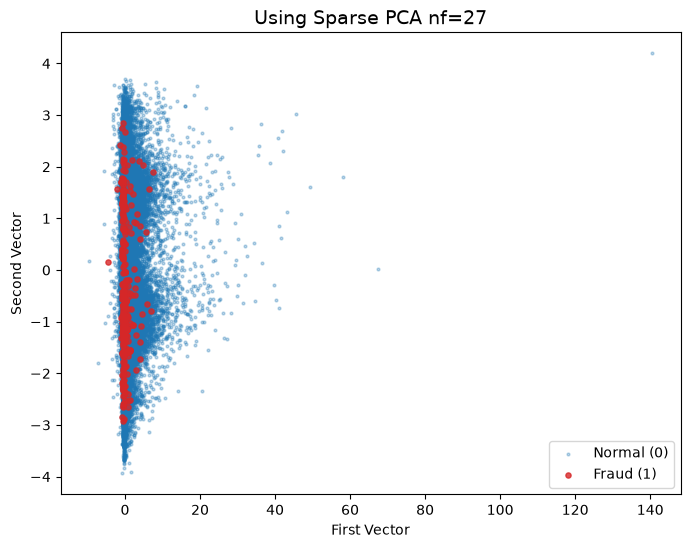

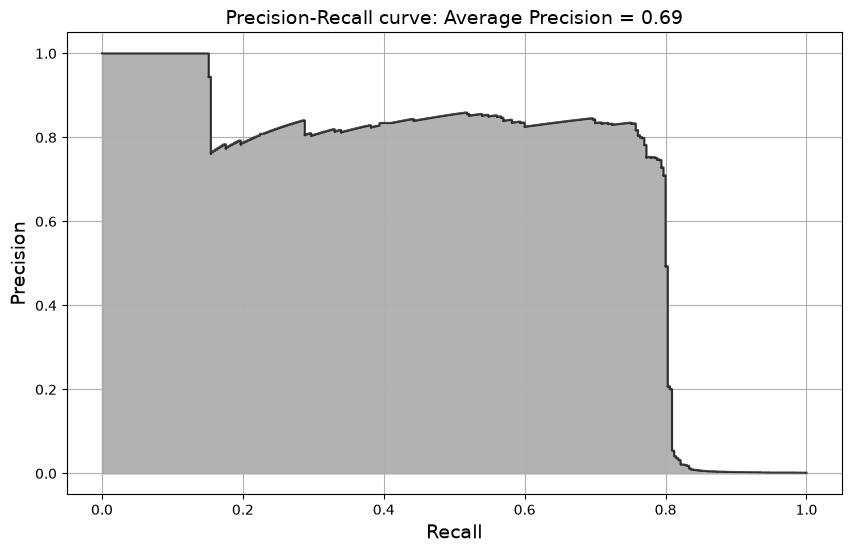

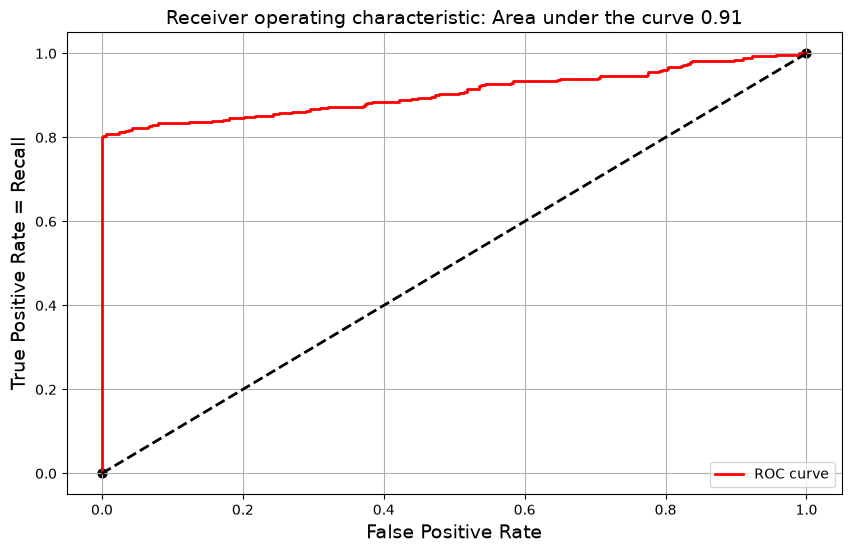

,True Labels,Anomaly Scores
0,0,0.000179
1,0,0.000030
2,0,0.000183
3,0,0.000135
4,0,0.000419
...,...,...
190815,0,0.000102
190816,0,0.000042
190817,0,0.000111
190818,0,0.000149


In [21]:
## alpha --> degree of sparsity
pca_sparse = SparsePCA(n_components=27, random_state=2018, n_jobs=-1, alpha=0.0001)

## Fit and transform for train, transform only for test
X_train_reduced_sparse = pca_sparse.fit_transform(X_train_final)

## Inverse (Reconstruct) -- SparsePCA has inverse_transform (it adds the mean back for us)
X_train_inverse_sparse = pca_sparse.inverse_transform(X_train_reduced_sparse)

## Call the ScatterPlot Function
plot_two_comp(X_reduced=X_train_reduced_sparse, y_true=y_train, algo_name='Sparse PCA nf=27')


## Getting Anomaly Scores -- call the function
y_scores_sparse = anomaly_scores(X_original=X_train_final, X_reconstructed=X_train_inverse_sparse)

## Plotting Evaluation plots -- call the function
df_sparse = evaluate_score(y_true=y_train, y_anomaly_scores=y_scores_sparse, return_df=True)
df_sparse


### `Kernel PCA`

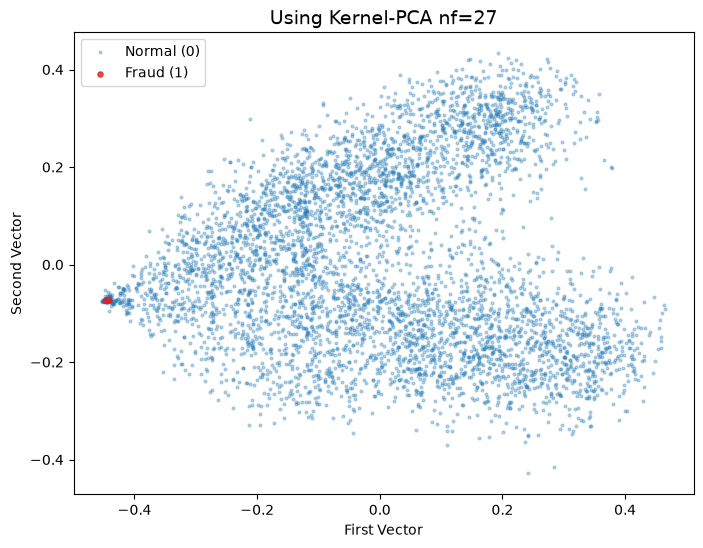

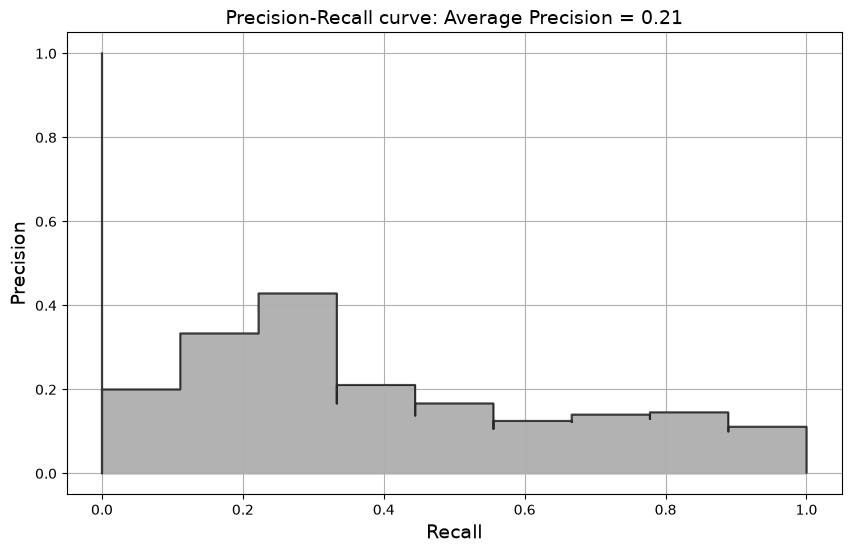

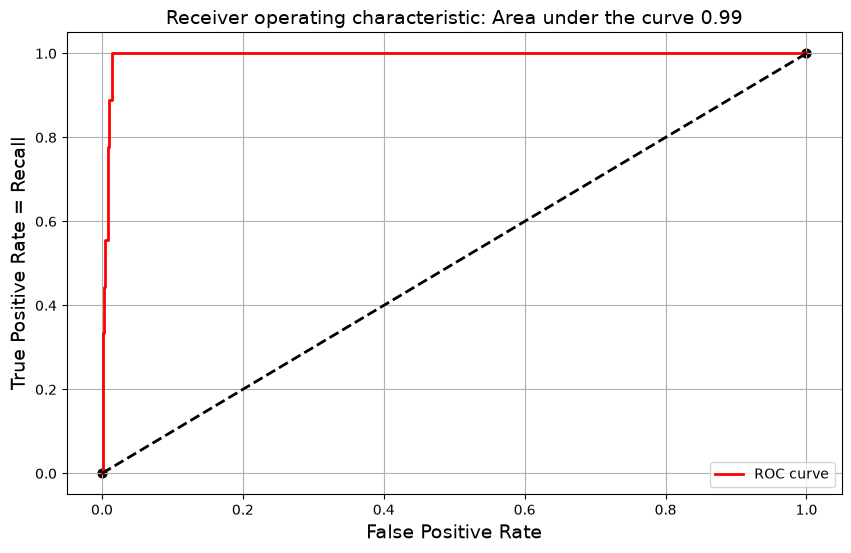

,True Labels,Anomaly Scores
0,0,0.000600
1,0,0.009726
2,0,0.000011
3,0,0.000009
4,0,0.000969
...,...,...
4995,0,0.000375
4996,0,0.000038
4997,0,0.002112
4998,0,0.000044


In [22]:
## Try to use KernelPCA
## KernelPCA builds an (n x n) kernel matrix, so we cannot use all the 190K training rows (it takes much time and memory)
## We take a random subsample, STRATIFIED, so that the rare fraud cases are still in it
## (before it was the first 2000 rows only, which contains almost no fraud)
_, X_sub_kernel, _, y_sub_kernel = train_test_split(X_train_final, y_train, test_size=5000,
                                                    random_state=2018, stratify=y_train)

## Try (gamma) = 1/number of Features  (gamma=None)
## fit_inverse_transform=True --> to allow the inverse_transform function
pca_kernel = KernelPCA(n_components=27, random_state=2018, n_jobs=-1, kernel='rbf', gamma=None, fit_inverse_transform=True)

## Fit and transform
X_train_reduced_kernel = pca_kernel.fit_transform(X_sub_kernel)

## Inverse (Reconstruct)
X_train_inverse_kernel = pca_kernel.inverse_transform(X_train_reduced_kernel)

## Call the ScatterPlot Function
plot_two_comp(X_reduced=X_train_reduced_kernel, y_true=y_sub_kernel, algo_name='Kernel-PCA nf=27')

## Getting Anomaly Scores -- call the function
y_scores_kernel = anomaly_scores(X_original=X_sub_kernel, X_reconstructed=X_train_inverse_kernel)

## Plotting Evaluation plots -- call the function
## Take care: the subsample has only a few fraud cases, so these metrics are noisy and not comparable with the other methods
df_kernel = evaluate_score(y_true=y_sub_kernel, y_anomaly_scores=y_scores_kernel, return_df=True)
df_kernel


### `Gaussian Random Projection`

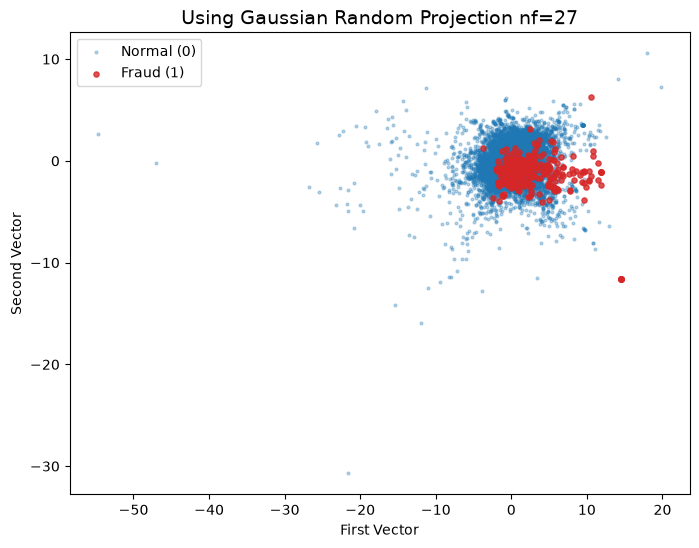

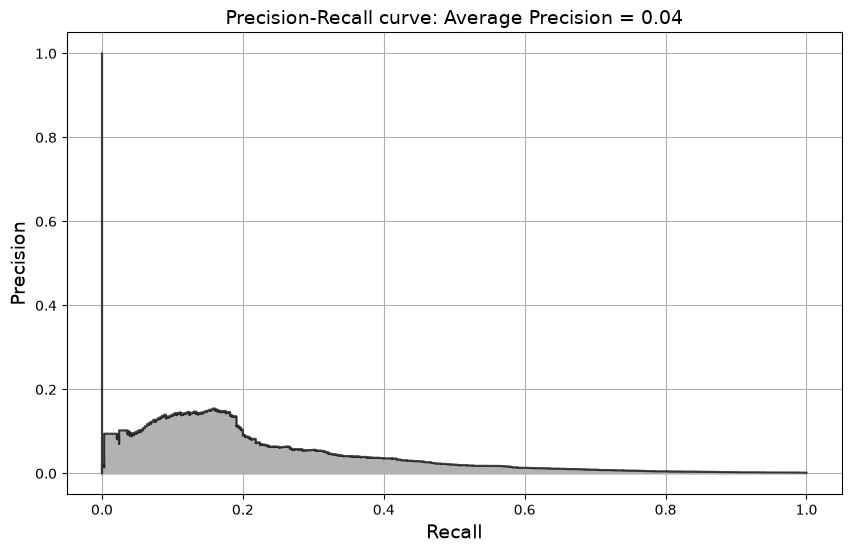

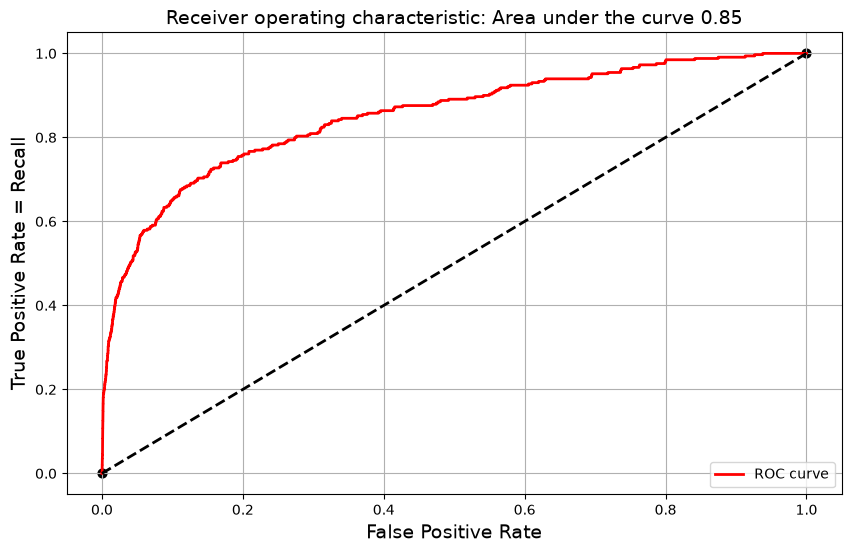

,True Labels,Anomaly Scores
0,0,0.000500
1,0,0.000698
2,0,0.001114
3,0,0.000369
4,0,0.000170
...,...,...
190815,0,0.000064
190816,0,0.001422
190817,0,0.000724
190818,0,0.000414


In [23]:
## Try to use Gaussian Random projection
## Here we use n_components (eps is ignored when n_components is given, so we leave it as default)
## compute_inverse_components=True --> to allow the inverse_transform function (pseudo-inverse of the random matrix)
gauss_proj = GaussianRandomProjection(n_components=27, random_state=2018, compute_inverse_components=True)

## Fit and transform for train, transform only for test
X_train_reduced_gauss = gauss_proj.fit_transform(X_train_final)

## Inverse (Reconstruct) -- the random matrix is NOT orthonormal, so we must use its pseudo-inverse (not .components_)
X_train_inverse_gauss = gauss_proj.inverse_transform(X_train_reduced_gauss)

## Call the ScatterPlot Function
plot_two_comp(X_reduced=X_train_reduced_gauss, y_true=y_train, algo_name='Gaussian Random Projection nf=27')

## Getting Anomaly Scores -- call the function
y_scores_gauss = anomaly_scores(X_original=X_train_final, X_reconstructed=X_train_inverse_gauss)

## Plotting Evaluation plots -- call the function
df_gauss = evaluate_score(y_true=y_train, y_anomaly_scores=y_scores_gauss, return_df=True)
df_gauss


### `Dictionary Learning`
`NonLinear Dimens. Reduction`

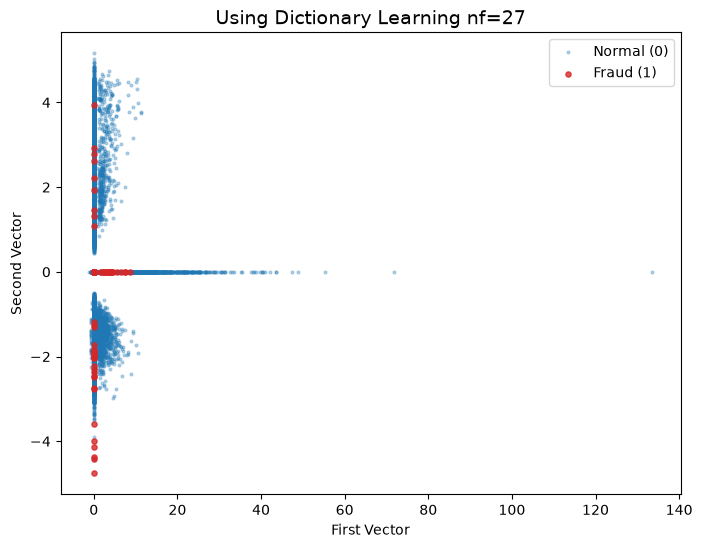

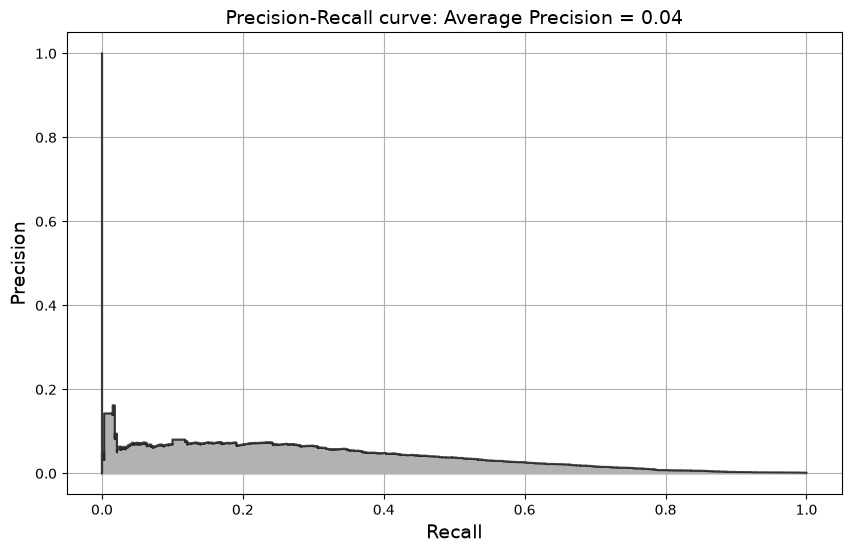

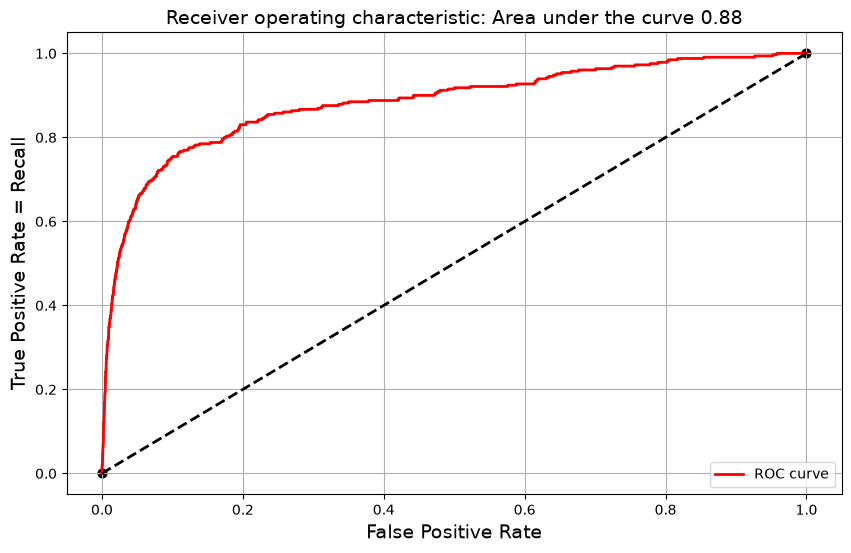

,True Labels,Anomaly Scores
0,0,0.000859
1,0,0.001084
2,0,0.002341
3,0,0.000717
4,0,0.001480
...,...,...
190815,0,0.001124
190816,0,0.001862
190817,0,0.002460
190818,0,0.001729


In [24]:
## Dictionary Learning is method for non-linear dimens. reduction (manifold)
## In our case, we will generate 27 vectors (or components).
## To learn the dictionary, we feed in mini-batches of 200 samples (max_iter = max number of passes over the data)
dict_learn = MiniBatchDictionaryLearning(n_components=27, random_state=2018, n_jobs=-1, max_iter=10, batch_size=200, alpha=1)

## Fit and transform for train, transform only for test
X_train_reduced_dict = dict_learn.fit_transform(X_train_final)

## Dictionary Learning -- doesn't have (inverse_transform) function We do it manually
X_train_inverse_dict = (X_train_reduced_dict @ dict_learn.components_)

## Call the ScatterPlot Function
plot_two_comp(X_reduced=X_train_reduced_dict, y_true=y_train, algo_name='Dictionary Learning nf=27')

## Getting Anomaly Scores -- call the function
y_scores_dict = anomaly_scores(X_original=X_train_final, X_reconstructed=X_train_inverse_dict)

## Plotting Evaluation plots -- call the function
df_dict = evaluate_score(y_true=y_train, y_anomaly_scores=y_scores_dict, return_df=True)
df_dict


### `Independent Component Analysis (ICA)`

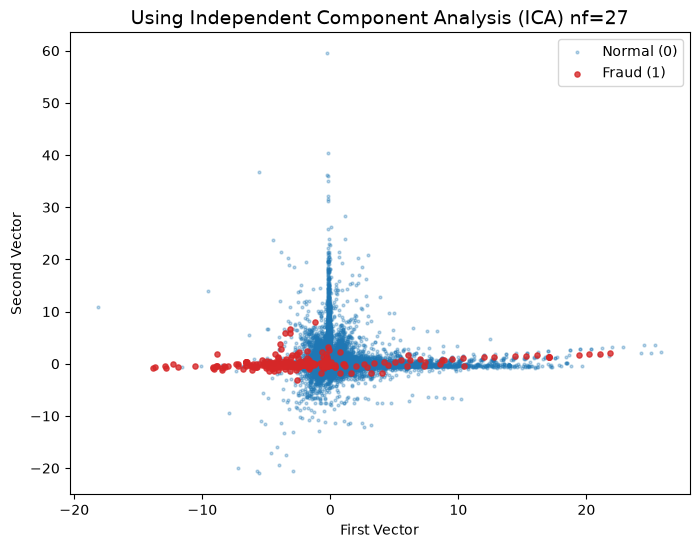

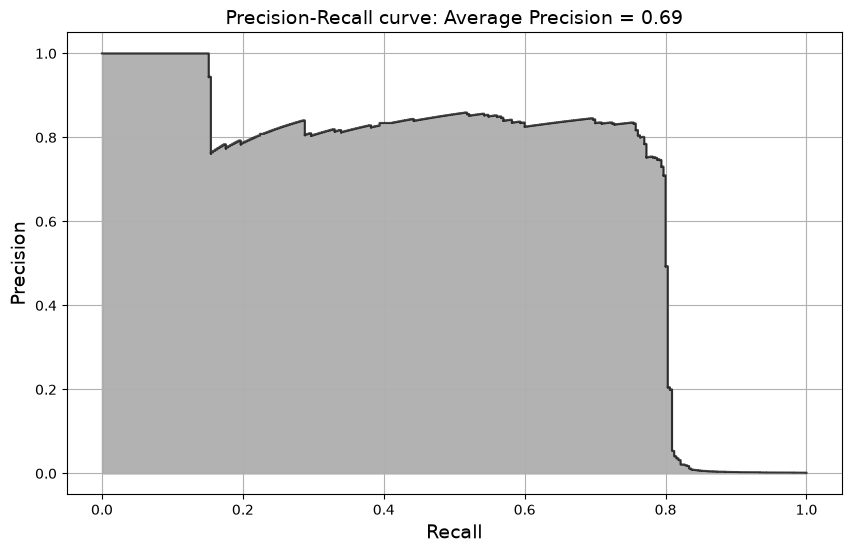

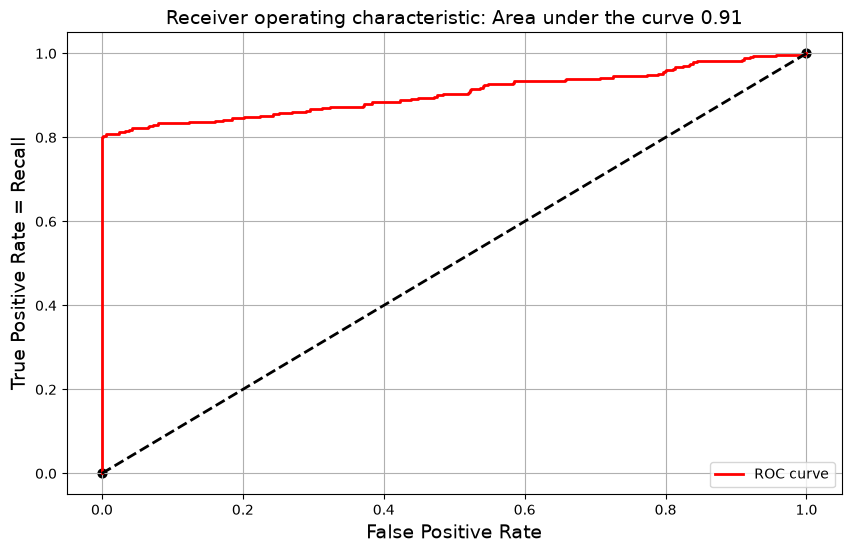

,True Labels,Anomaly Scores
0,0,0.000179
1,0,0.000029
2,0,0.000182
3,0,0.000135
4,0,0.000418
...,...,...
190815,0,0.000102
190816,0,0.000039
190817,0,0.000110
190818,0,0.000149


In [25]:
## try ICA (ICA is familiar for signal processing)
ica = FastICA(n_components=27, algorithm='parallel', max_iter=200, random_state=2018)

## Fit and transform for train, transform only for test
X_train_reduced_ica = ica.fit_transform(X_train_final)

## Inverse (Reconstruct) -- FastICA has inverse_transform
X_train_inverse_ica = ica.inverse_transform(X_train_reduced_ica)

## Call the ScatterPlot Function
plot_two_comp(X_reduced=X_train_reduced_ica, y_true=y_train, algo_name='Independent Component Analysis (ICA) nf=27')

## Getting Anomaly Scores -- call the function
y_scores_ica = anomaly_scores(X_original=X_train_final, X_reconstructed=X_train_inverse_ica)

## Plotting Evaluation plots -- call the function
df_ica = evaluate_score(y_true=y_train, y_anomaly_scores=y_scores_ica, return_df=True)
df_ica


### `The Results using Normal PCA is almost the same using ICA --- (The best results)`

-------

### `Apply on Test Dataset`

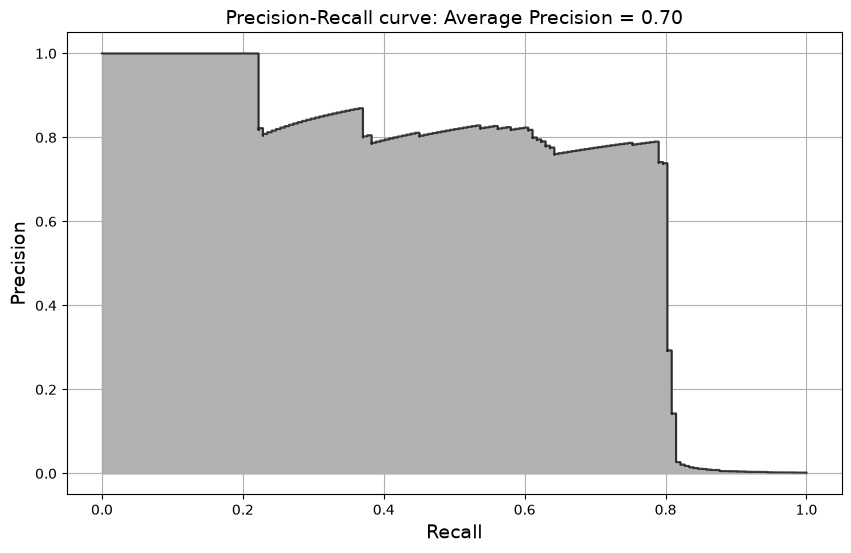

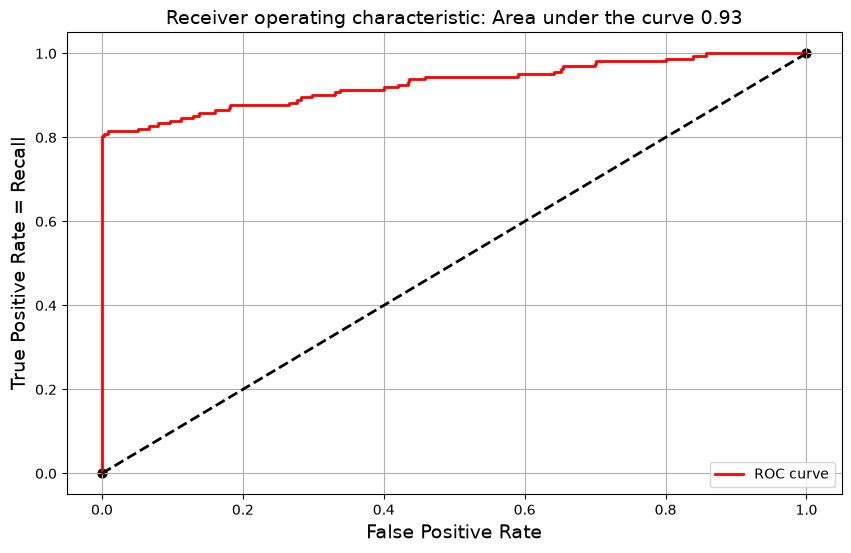

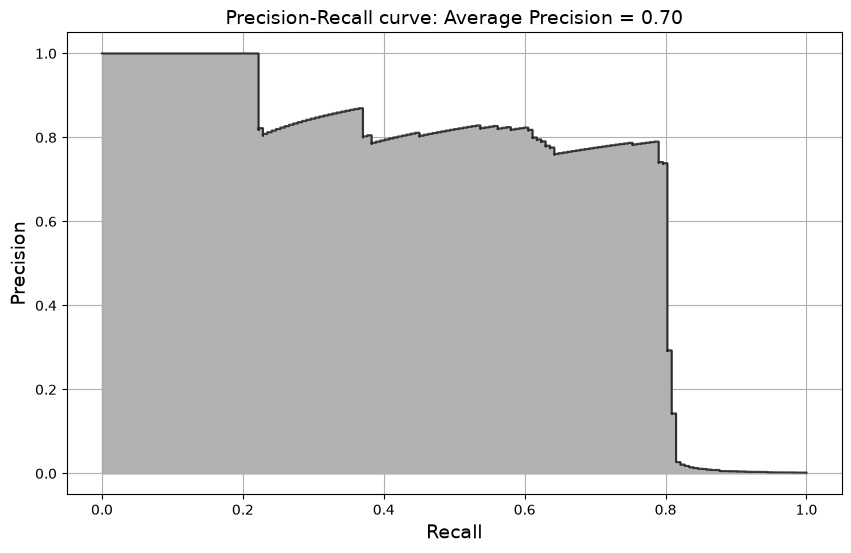

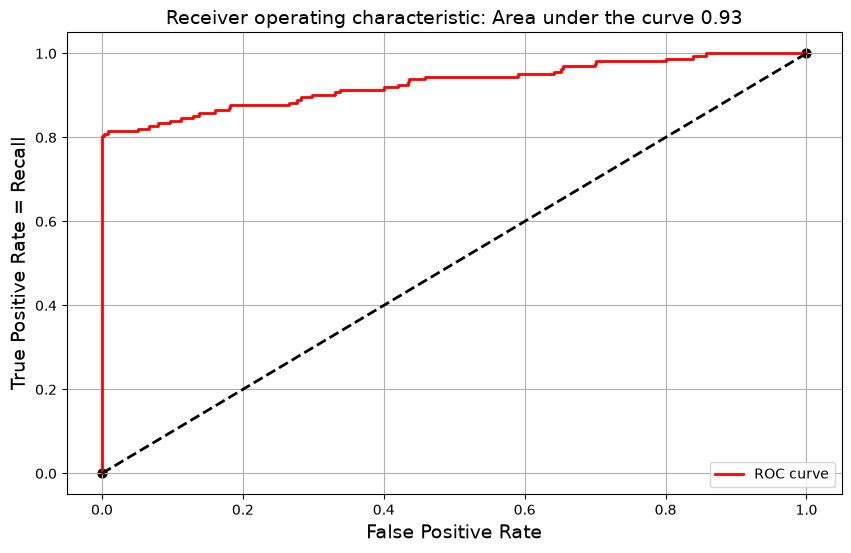

In [26]:
## Apply for Normal PCA & ICA -- The best Results
## Take care: the scaler, PCA and ICA were fitted on TRAIN only, here we only (transform) the test set
## The min-max range of the scores is taken from the TRAIN losses, so train and test scores are on the same scale

## ---- Normal PCA (27 components)
X_test_reduced_pca_27 = pca_27.transform(X_test_final)
X_test_inverse_pca_27 = pca_27.inverse_transform(X_test_reduced_pca_27)

train_loss_pca27 = reconstruction_error(X_train_final, X_train_inverse_pca_27)
y_scores_test_pca27 = anomaly_scores(X_original=X_test_final, X_reconstructed=X_test_inverse_pca_27,
                                     loss_min=train_loss_pca27.min(), loss_max=train_loss_pca27.max())
df_test_pca27 = evaluate_score(y_true=y_test, y_anomaly_scores=y_scores_test_pca27, return_df=True)

## ---- ICA (27 components)
X_test_reduced_ica = ica.transform(X_test_final)
X_test_inverse_ica = ica.inverse_transform(X_test_reduced_ica)

train_loss_ica = reconstruction_error(X_train_final, X_train_inverse_ica)
y_scores_test_ica = anomaly_scores(X_original=X_test_final, X_reconstructed=X_test_inverse_ica,
                                   loss_min=train_loss_ica.min(), loss_max=train_loss_ica.max())
df_test_ica = evaluate_score(y_true=y_test, y_anomaly_scores=y_scores_test_ica, return_df=True)
